
# Influence-based Royalty Allocation (Revised)

This notebook allocates royalties to training points based on their **influence scores** on generated samples.

**Data layout**
- `S` has shape `[N_train, N_gen]` (here: `[28000, 500]`).
- Column `j` holds the influence of every training point `i` on generated sample `j`.
- Per-sample allocations are aggregated into a final **royalty distribution** over the training set.

**Allocation families**
- **Top-K (equal split):** each generated sample pays only its Top-K most influential training points, evenly.
- **Top-K (proportional):** each generated sample pays only its Top-K, proportionally to their (preprocessed) scores.
- **Inverse-ranking:** weights are `1 / rank^p` (optionally capped at top-`m`), then normalized per sample.
- **Soft-power weighting:** weights proportional to `score^alpha`, normalized per sample.

**Inequality metrics**
- **Gini coefficient**
- **Atkinson index** (\\(\\epsilon\\in\\{0.5, 1.0, 2.0\\}\\))
- **Herfindahl–Hirschman Index (HHI)**
- Top 1% / 10% share, max share

**Visualizations (only)**
- Lorenz curve
- Histogram of royalties

> Notes:
> - Default preprocessing uses **positive-only** influence (`ReLU`) so that negative influence does not receive royalties.
> - If, for a generated sample, all (preprocessed) influences are zero, that sample contributes nothing; final distributions are re-normalized to sum to 1.


In [1]:

import math
from typing import Dict

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.6f}")


In [2]:

# --- Configuration ---
S_PATH = "/home/xiruij/anticipation/checkpoints_subset_large/score_LoGra_4096_gen.pt"
N_TRAIN = 28000
N_GEN = 500

# Preprocess influences before allocation:
#   'positive' : clamp negatives to 0 (default)
#   'shift'    : shift by global min so the minimum becomes 0
#   'absolute' : use absolute values
#   'raw'      : use raw influences as-is
PREPROCESS = "shift"

# Optional: weights per generated sample (e.g., by importance). If None, all equal.
SAMPLE_WEIGHTS = None  # torch.Tensor of shape [N_GEN] or None

PARAMS = {
    "topk_equal": {"k": 500},
    "topk_prop":  {"k": 500},
    "inverse_rank": {"m": 500, "p": 1.0},
    "soft_power": {"alpha": 1.0},
}

DEVICE = "cpu"


In [3]:

# --- Load S ---
S = torch.load(S_PATH, map_location=DEVICE)
assert S.ndim == 2, "Expected 2D tensor [N_train, N_gen]"
print("Loaded S with shape:", tuple(S.shape), "dtype:", S.dtype)


Loaded S with shape: (28000, 500) dtype: torch.float32


/tmp/ipykernel_2248716/448449236.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  S = torch.load(S_PATH, map_location=DEVICE)


In [4]:

# --- Preprocessing & utilities ---
def preprocess_scores(S: torch.Tensor, mode: str = "positive") -> torch.Tensor:
    if mode == "positive":
        return torch.clamp(S, min=0)
    if mode == "shift":
        return S - torch.min(S)
    if mode == "absolute":
        return torch.abs(S)
    if mode == "raw":
        return S
    raise ValueError("Unknown preprocess mode")

def column_normalize(W: torch.Tensor) -> torch.Tensor:
    col_sums = W.sum(dim=0, keepdim=True)
    W = torch.where(col_sums > 0, W / col_sums, W)
    return W

def aggregate(W: torch.Tensor, sample_weights: torch.Tensor = None) -> torch.Tensor:
    if sample_weights is None:
        p = W.sum(dim=1)
    else:
        p = (W * sample_weights[None, :]).sum(dim=1)
    p = p / p.sum()
    return p

# Metrics
def gini(x: torch.Tensor) -> float:
    n = x.numel()
    xs = torch.sort(x)[0]
    i = torch.arange(1, n + 1, dtype=xs.dtype, device=xs.device)
    G = (2 * torch.sum(i * xs) / (n * torch.sum(xs))) - (n + 1) / n
    return float(G)

def atkinson(x: torch.Tensor, epsilon: float) -> float:
    mu = x.mean()
    if epsilon == 1.0:
        gm = torch.exp(torch.mean(torch.log(torch.clamp(x, min=1e-20))))
        return float(1.0 - (gm / mu))
    p = 1.0 - epsilon
    term = torch.mean(torch.pow(x, p))
    return float(1.0 - (term ** (1.0 / p)) / mu)

def top_share(x: torch.Tensor, frac: float) -> float:
    n = x.numel()
    k = max(1, int(round(frac * n)))
    xs = torch.sort(x, descending=True)[0]
    return float(xs[:k].sum().item())

def hhi(x: torch.Tensor) -> float:
    return float(torch.sum(x * x).item())

# Visualization helpers (only Lorenz + Histogram)
def plot_lorenz(x: torch.Tensor, title: str):
    xs = torch.sort(x)[0]
    cumx = torch.cumsum(xs, dim=0)
    n = xs.numel()
    lorenz_x = np.linspace(0, 1, n + 1)
    lorenz_y = np.concatenate([[0.0], cumx.cpu().numpy() / cumx[-1].item()])
    plt.figure()
    plt.plot(lorenz_x, lorenz_y, linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"Lorenz Curve — {title}")
    plt.xlabel("Population share")
    plt.ylabel("Cumulative royalty share")
    plt.show()

def plot_hist(x: torch.Tensor, title: str, bins: int = 100):
    plt.figure()
    plt.hist(x.cpu().numpy(), bins=bins)
    plt.yscale("log")
    plt.title(f"Royalty Distribution Histogram — {title}")
    plt.xlabel("Royalty share per training point")
    plt.ylabel("Count (log scale)")
    plt.show()


In [5]:

# --- Allocation methods ---
def precompute_order(Spp: torch.Tensor) -> torch.Tensor:
    return torch.argsort(Spp, dim=0, descending=True)

def allocate_topk_equal(Spp: torch.Tensor, k: int, idx_desc: torch.Tensor = None) -> torch.Tensor:
    if idx_desc is None:
        idx_desc = precompute_order(Spp)
    W = torch.zeros_like(Spp)
    top_idx = idx_desc[:k, :]
    W.scatter_(0, top_idx, torch.ones_like(top_idx, dtype=Spp.dtype))
    W = W / k
    return column_normalize(W)

def allocate_topk_prop(Spp: torch.Tensor, k: int, idx_desc: torch.Tensor = None) -> torch.Tensor:
    if idx_desc is None:
        idx_desc = precompute_order(Spp)
    W = torch.zeros_like(Spp)
    top_idx = idx_desc[:k, :]
    top_vals = Spp.gather(0, top_idx)
    col_norm = top_vals.sum(dim=0, keepdim=True)
    weights = torch.where(col_norm > 0, top_vals / col_norm, torch.zeros_like(top_vals))
    W.scatter_(0, top_idx, weights)
    return column_normalize(W)

def allocate_inverse_rank(Spp: torch.Tensor, m: int = None, p: float = 1.0, idx_desc: torch.Tensor = None) -> torch.Tensor:
    n, g = Spp.shape
    if idx_desc is None:
        idx_desc = precompute_order(Spp)
    ranks = torch.arange(1, n + 1, device=Spp.device, dtype=Spp.dtype).unsqueeze(1).expand(n, g)
    weights = 1.0 / torch.pow(ranks, p)
    if m is not None:
        weights[m:, :] = 0.0
    W = torch.zeros_like(Spp)
    W.scatter_(0, idx_desc, weights)
    return column_normalize(W)

def allocate_soft_power(Spp: torch.Tensor, alpha: float = 1.0) -> torch.Tensor:
    W = torch.pow(Spp, alpha)
    return column_normalize(W)


In [6]:

# --- Run methods & metrics ---
Spp = preprocess_scores(S, PREPROCESS).to(DEVICE)
idx_desc = precompute_order(Spp)
sample_weights = SAMPLE_WEIGHTS if SAMPLE_WEIGHTS is None else SAMPLE_WEIGHTS.to(DEVICE)

methods = {
    "Top-K (equal)": allocate_topk_equal(Spp, **PARAMS["topk_equal"], idx_desc=idx_desc),
    "Top-K (proportional)": allocate_topk_prop(Spp, **PARAMS["topk_prop"], idx_desc=idx_desc),
    "Inverse-ranking": allocate_inverse_rank(Spp, **PARAMS["inverse_rank"], idx_desc=idx_desc),
    "Soft-power": allocate_soft_power(Spp, **PARAMS["soft_power"]),
}

results: Dict[str, Dict] = {}
for name, W in methods.items():
    p = aggregate(W, sample_weights=sample_weights)
    metrics = {
        "Gini": gini(p),
        "Atkinson (eps=0.5)": atkinson(p, 0.5),
        "Atkinson (eps=1.0)": atkinson(p, 1.0),
        "Atkinson (eps=2.0)": atkinson(p, 2.0),
        "Top 1% share": top_share(p, 0.01),
        "Top 10% share": top_share(p, 0.10),
        "Max share": float(p.max().item()),
        "HHI": hhi(p),
    }
    results[name] = {"p": p, "metrics": metrics}

summary_df = pd.DataFrame({k: v["metrics"] for k, v in results.items()}).T
summary_df = summary_df[["Gini", "Atkinson (eps=0.5)", "Atkinson (eps=1.0)", "Atkinson (eps=2.0)", "Top 1% share", "Top 10% share", "Max share", "HHI"]]
summary_df.sort_values("Gini", ascending=False, inplace=True)
summary_df


,Gini,Atkinson (eps=0.5),Atkinson (eps=1.0),Atkinson (eps=2.0),Top 1% share,Top 10% share,Max share,HHI
Inverse-ranking,0.532097,0.233355,0.402533,1.000000,0.098711,0.432003,0.000751,0.000110
Top-K (proportional),0.229658,0.044096,0.104751,1.000000,0.023678,0.180536,0.000122,0.000042
Top-K (equal),0.225590,0.043123,0.103169,1.000000,0.023196,0.178732,0.000116,0.000042
Soft-power,0.001543,0.000002,0.000005,0.000008,0.010124,0.100599,0.000037,0.000036


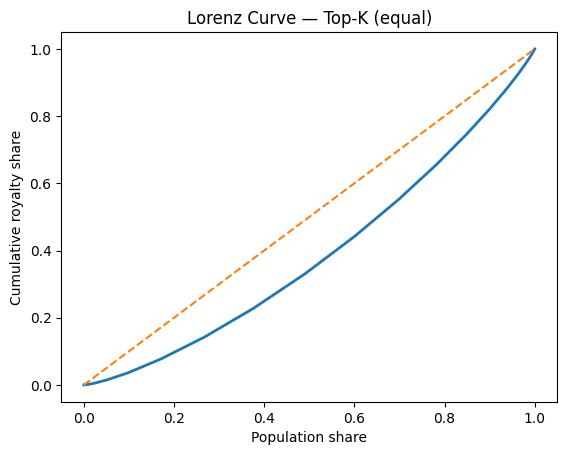

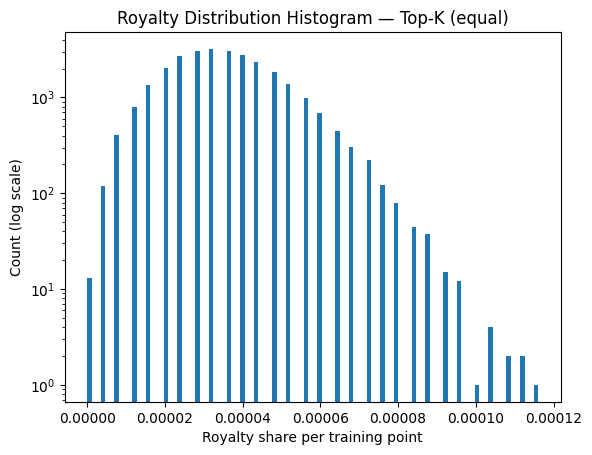

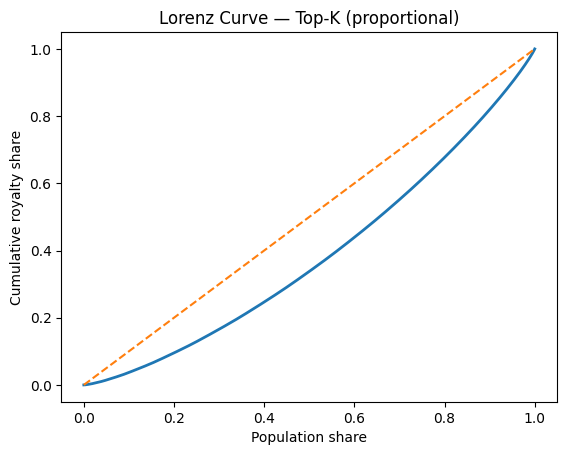

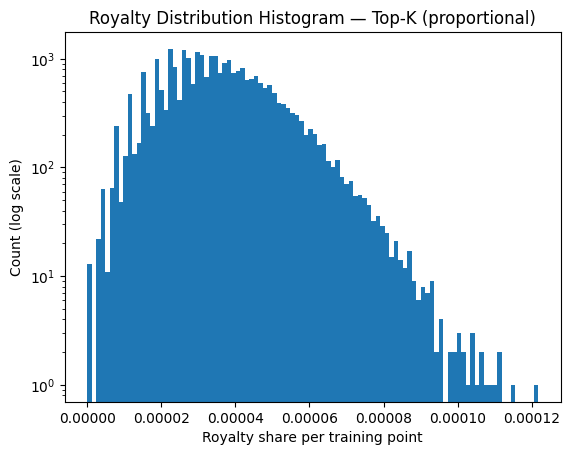

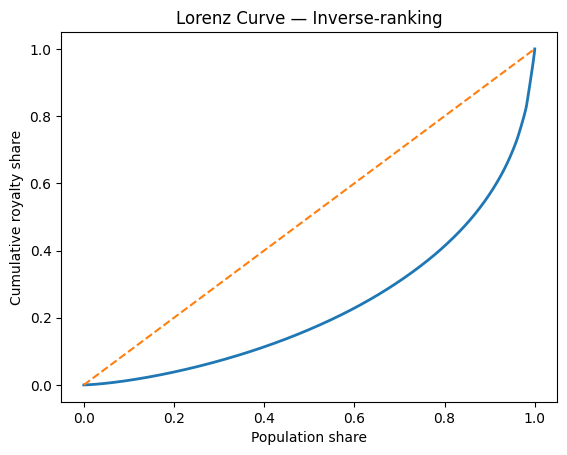

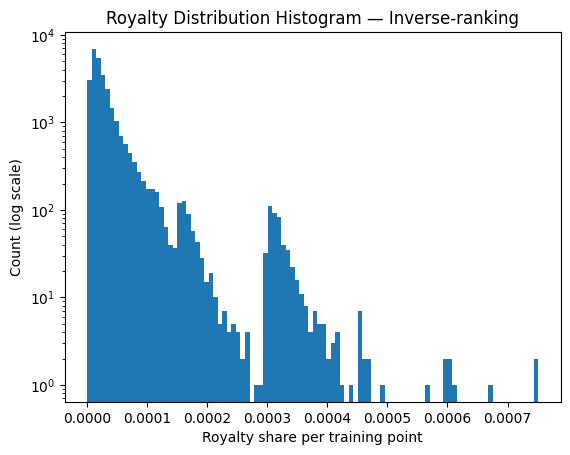

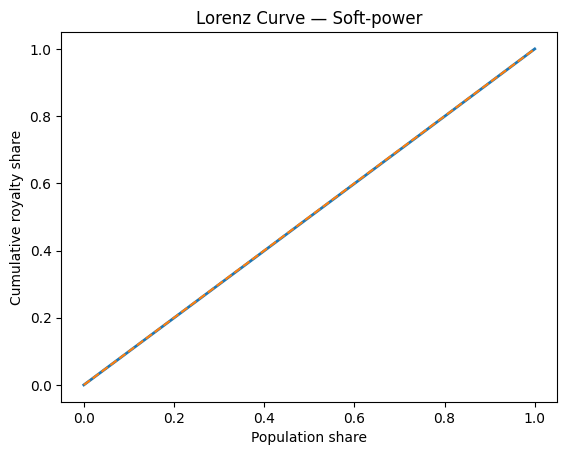

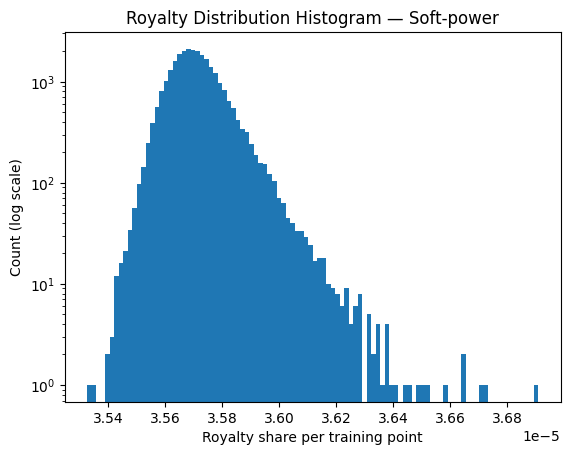

In [7]:

# --- Visualizations (Lorenz + Histogram only) ---
for name, obj in results.items():
    p = obj["p"]
    plot_lorenz(p, name)
    plot_hist(p, name, bins=100)



## Sensitivity Analyses

We sweep key hyperparameters and track inequality metrics.


In [8]:

# --- Top-K sweep ---
K_list = [1, 10, 50, 100, 500]
rows = []
for k in K_list:
    W = allocate_topk_equal(Spp, k=k, idx_desc=idx_desc)
    p = aggregate(W, sample_weights=sample_weights)
    rows.append({"K": k, "Gini": gini(p), "Top 1% share": top_share(p, 0.01), "Top 10% share": top_share(p, 0.10)})
topk_sweep_df = pd.DataFrame(rows)
topk_sweep_df


,K,Gini,Top 1% share,Top 10% share
0,1,0.982635,0.574000,1.000000
1,10,0.850935,0.118600,0.650200
2,50,0.563683,0.049120,0.322480
3,100,0.429670,0.036420,0.260260
4,500,0.225590,0.023196,0.178732


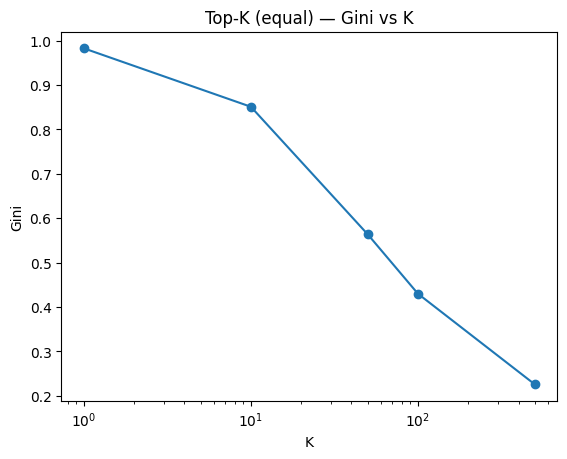

In [9]:

plt.figure()
plt.plot(topk_sweep_df["K"], topk_sweep_df["Gini"], marker="o")
plt.title("Top-K (equal) — Gini vs K")
plt.xlabel("K")
plt.ylabel("Gini")
plt.xscale("log")
plt.show()


In [10]:

# --- Inverse-ranking sweep over p ---
P_list = [0.5, 1.0, 1.5, 2.0]
rows = []
for pwr in P_list:
    W = allocate_inverse_rank(Spp, m=PARAMS["inverse_rank"]["m"], p=pwr, idx_desc=idx_desc)
    p = aggregate(W, sample_weights=sample_weights)
    rows.append({"p": pwr, "Gini": gini(p), "Top 1% share": top_share(p, 0.01), "Top 10% share": top_share(p, 0.10)})
inv_sweep_df = pd.DataFrame(rows)
inv_sweep_df


,p,Gini,Top 1% share,Top 10% share
0,0.500000,0.272700,0.028662,0.205041
1,1.000000,0.532097,0.098711,0.432003
2,1.500000,0.812522,0.239783,0.753437
3,2.000000,0.925327,0.358536,0.916532


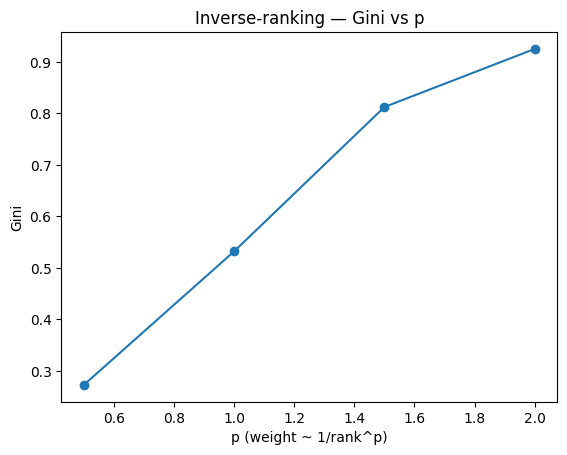

In [11]:

plt.figure()
plt.plot(inv_sweep_df["p"], inv_sweep_df["Gini"], marker="o")
plt.title("Inverse-ranking — Gini vs p")
plt.xlabel("p (weight ~ 1/rank^p)")
plt.ylabel("Gini")
plt.show()


In [12]:

# --- Soft-power sweep over alpha ---
ALPHA_list = [0.5, 1.0, 2.0, 4.0]
rows = []
for a in ALPHA_list:
    W = allocate_soft_power(Spp, alpha=a)
    p = aggregate(W, sample_weights=sample_weights)
    rows.append({"alpha": a, "Gini": gini(p), "Top 1% share": top_share(p, 0.01), "Top 10% share": top_share(p, 0.10)})
soft_sweep_df = pd.DataFrame(rows)
soft_sweep_df


,alpha,Gini,Top 1% share,Top 10% share
0,0.500000,0.000673,0.010040,0.100233
1,1.000000,0.001543,0.010124,0.100599
2,2.000000,0.005070,0.010955,0.102736
3,4.000000,0.070485,0.049052,0.158707


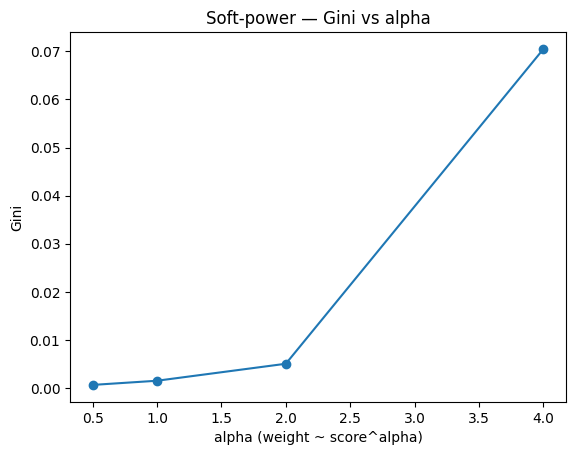

In [13]:

plt.figure()
plt.plot(soft_sweep_df["alpha"], soft_sweep_df["Gini"], marker="o")
plt.title("Soft-power — Gini vs alpha")
plt.xlabel("alpha (weight ~ score^alpha)")
plt.ylabel("Gini")
plt.show()


In [14]:
# --- Map training sample IDs to usernames and aggregate royalties per user ---
import warnings

TRAIN_PATH = "/home/xiruij/anticipation/datasets/finetune/train_v2.txt"
META_CSV = "/home/xiruij/anticipation/tt_data_hashed.csv"
ID_COL = "id"           # column name in META_CSV holding hashed id
USER_COL = "artist"     # treat artist as username per sample

# 1) Parse training sample ids: last whitespace-separated token per line
train_ids = []
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        tok = line.split()
        train_ids.append(tok[-1])

train_ids = pd.Series(train_ids, name="id")

# Validate length vs N_TRAIN
if len(train_ids) != N_TRAIN:
    warnings.warn(f"Parsed {len(train_ids)} ids from train file, but N_TRAIN={N_TRAIN}.")

# 2) Load id->username mapping
meta = pd.read_csv(META_CSV)
if ID_COL not in meta.columns or USER_COL not in meta.columns:
    raise ValueError(f"CSV must contain columns '{ID_COL}' and '{USER_COL}'. Columns: {list(meta.columns)}")

id_to_user = pd.Series(meta[USER_COL].values, index=meta[ID_COL].values)

# 3) Build mapping for all training ids, warning on misses
users = []
num_missing = 0
missing_examples = []
for tid in train_ids:
    if tid in id_to_user.index:
        users.append(id_to_user.loc[tid])
    else:
        users.append(None)
        num_missing += 1
        if len(missing_examples) < 5:
            missing_examples.append(tid)

if num_missing > 0:
    warnings.warn(
        f"{num_missing} / {len(train_ids)} training ids not found in metadata. Examples: {missing_examples}"
    )

users = pd.Series(users, name="user")

# 4) Convert per-training-point royalty vectors to DataFrame
# 'results' dict exists from previous cells: { method: { 'p': tensor, 'metrics': ... } }
royalty_frames = {}
for method_name, obj in results.items():
    p = obj["p"].detach().cpu().numpy()
    df = pd.DataFrame({"id": train_ids.values, "user": users.values, "royalty": p})
    royalty_frames[method_name] = df

# 5) Aggregate by user (ignoring missing users)
user_aggregates = {}
for method_name, df in royalty_frames.items():
    agg = df.dropna(subset=["user"]).groupby("user", as_index=False)["royalty"].sum()
    agg.sort_values("royalty", ascending=False, inplace=True)
    agg.reset_index(drop=True, inplace=True)
    user_aggregates[method_name] = agg

# 6) Display top users per method
TOP_N = 20
for method_name, agg in user_aggregates.items():
    print(f"\n=== Top {TOP_N} users — {method_name} ===")
    display(agg.head(TOP_N))



=== Top 20 users — Top-K (equal) ===


/tmp/ipykernel_2248716/733972637.py:46: UserWarning: 26763 / 28000 training ids not found in metadata. Examples: ['AQodXZnqoDl', 'DpgvlGZOoad', 'Dpgv_Qwdxad', 'DpgvZEpBgad', 'AQodQjlpmDl']
  warnings.warn(


,user,royalty
0,Kevin MacLeod,0.001336
1,ZUN,0.001024
2,Boards Of Canada,0.000900
3,K3,0.000648
4,Nintendo,0.000576
5,Supastition,0.000544
6,Taylor Swift,0.000532
7,Benjamin Ingrosso,0.000532
8,Fleet Foxes,0.000528
9,Roar,0.000492



=== Top 20 users — Top-K (proportional) ===


,user,royalty
0,Kevin MacLeod,0.001313
1,ZUN,0.001001
2,Boards Of Canada,0.000852
3,Supastition,0.000608
4,K3,0.000607
5,Nintendo,0.000588
6,Taylor Swift,0.000548
7,Fleet Foxes,0.000535
8,Gorillaz,0.000526
9,Benjamin Ingrosso,0.000511



=== Top 20 users — Inverse-ranking ===


,user,royalty
0,Nintendo,0.001911
1,Gorillaz,0.001255
2,Supastition,0.001203
3,MIKA,0.000947
4,Phineas and Ferb,0.000903
5,Koei,0.000865
6,The Buggles,0.000829
7,Kevin MacLeod,0.000826
8,Real Estate,0.000813
9,Silent Partner,0.000789



=== Top 20 users — Soft-power ===


,user,royalty
0,Kevin MacLeod,0.001108
1,ZUN,0.000893
2,Boards Of Canada,0.000713
3,Sega,0.000678
4,K3,0.000677
5,Taylor Swift,0.000607
6,Gorillaz,0.000536
7,Nintendo,0.000536
8,Benjamin Ingrosso,0.000500
9,Roar,0.000500
